# 07 — Predict SSP Futures

**Goal:** Use the best model per poverty threshold to predict poverty under SSP1/4/5 scenarios.  
**Reads:** `data/processed/ssp_forecast_panel.csv`, `outputs/model_comparison.csv`, model `.pkl` files  
**Outputs:**
- `data/processed/predictions_ssp.csv` (dashboard-ready)
- `outputs/top10_highest_poverty.csv`
- `outputs/trajectory_plots/*.png`

## Imports and paths

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

DATA_PROCESSED = Path("../data/processed")
MODELS_DIR = Path("../models")
OUTPUTS_DIR = Path("../outputs")
TRAJ_DIR = OUTPUTS_DIR / "trajectory_plots"
TRAJ_DIR.mkdir(parents=True, exist_ok=True)

FEATURES = ["gdp_per_capita", "hdi", "control_of_corruption", "employment_agriculture", "gini"]
TARGETS = ["poverty_3", "poverty_8_30", "poverty_10"]  # poverty_4_20 excluded (poverty gap data)
NEEDS_SCALING = {"Ridge", "MLP"}

plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (10, 6)

## Identify best model per threshold

In [2]:
comparison = pd.read_csv(OUTPUTS_DIR / "model_comparison.csv")

best_models = {}
for target in TARGETS:
    row = comparison[comparison["Threshold"] == target].sort_values("R2", ascending=False).iloc[0]
    best_models[target] = row["Model"]
    print(f"{target}: best = {row['Model']} (R² = {row['R2']:.4f})")

print(f"\nBest models: {best_models}")

poverty_3: best = MLP (R² = 0.7449)
poverty_8_30: best = GAM (R² = 0.8832)
poverty_10: best = RandomForest (R² = 0.9079)

Best models: {'poverty_3': 'MLP', 'poverty_8_30': 'GAM', 'poverty_10': 'RandomForest'}


## Load forecast panel

In [3]:
forecast = pd.read_csv(DATA_PROCESSED / "ssp_forecast_panel.csv")
print(f"Forecast panel: {forecast.shape}")
print(f"Scenarios: {forecast['scenario'].unique()}")
print(f"Years: {sorted(forecast['year'].unique())}")
print(f"Countries: {forecast['country_name'].nunique()}")
forecast.head()

Forecast panel: (9045, 11)
Scenarios: ['SSP1' 'SSP4' 'SSP5']
Years: [2025, 2030, 2035, 2040, 2045, 2050, 2055, 2060, 2065, 2070, 2075, 2080, 2085, 2090, 2095]
Countries: 201


,country_name,country_code,scenario,year,gdp_per_capita,population,hdi,control_of_corruption,employment_agriculture,gini,is_extrapolated
0,Afghanistan,AFG,SSP1,2025,NaN,43.793695,NaN,NaN,47.48,33.139,False
1,Afghanistan,AFG,SSP1,2030,NaN,49.238560,NaN,NaN,45.09,32.813,False
2,Afghanistan,AFG,SSP1,2035,NaN,54.439767,NaN,NaN,41.00,31.837,False
3,Afghanistan,AFG,SSP1,2040,NaN,59.275958,NaN,NaN,36.16,30.440,False
4,Afghanistan,AFG,SSP1,2045,NaN,63.892211,NaN,NaN,30.96,29.079,False


## Generate predictions

For each poverty threshold, load the best model and predict on all valid forecast rows.  
- **Approach A:** years ≤ 2050  
- **Approach B:** all years up to 2100  
- Clip predictions to [0, 100]

In [4]:
all_predictions = []

for target in TARGETS:
    model_name = best_models[target]
    print(f"\n--- {target} using {model_name} ---")
    
    # Load model and scaler
    model = joblib.load(MODELS_DIR / f"{model_name}_{target}.pkl")
    scaler = joblib.load(MODELS_DIR / f"scaler_{target}.pkl")
    
    # Filter rows with all features present
    fc_valid = forecast.dropna(subset=FEATURES).copy()
    X = fc_valid[FEATURES].values
    
    # Scale if needed
    if model_name in NEEDS_SCALING:
        X = scaler.transform(X)
    
    # Predict
    preds = model.predict(X)
    preds = np.clip(preds, 0, 100)  # poverty is a percentage
    
    fc_valid["predicted_poverty"] = preds
    fc_valid["poverty_threshold"] = target
    
    # Approach A: years <= 2050
    approach_a = fc_valid[fc_valid["year"] <= 2050].copy()
    approach_a["approach"] = "A"
    
    # Approach B: all years (up to 2100)
    approach_b = fc_valid.copy()
    approach_b["approach"] = "B"
    
    all_predictions.append(approach_a)
    all_predictions.append(approach_b)
    
    print(f"  Approach A: {len(approach_a)} rows (≤2050)")
    print(f"  Approach B: {len(approach_b)} rows (all years)")
    print(f"  Prediction range: {preds.min():.2f} – {preds.max():.2f}")

print("\nDone.")


--- poverty_3 using MLP ---
  Approach A: 2700 rows (≤2050)
  Approach B: 6750 rows (all years)
  Prediction range: 0.00 – 85.36

--- poverty_8_30 using GAM ---
  Approach A: 2700 rows (≤2050)
  Approach B: 6750 rows (all years)
  Prediction range: 0.00 – 100.00

--- poverty_10 using RandomForest ---
  Approach A: 2700 rows (≤2050)
  Approach B: 6750 rows (all years)
  Prediction range: 0.22 – 98.89

Done.


In [5]:
# Combine all predictions
predictions = pd.concat(all_predictions, ignore_index=True)

# Keep the columns the dashboard needs, including the feature values used for each prediction
output_cols = [
    "country_name", "country_code", "scenario", "year",
    "poverty_threshold", "predicted_poverty", "approach",
    "gdp_per_capita", "population", "hdi", "control_of_corruption",
    "employment_agriculture", "gini",
]
predictions = predictions[output_cols].sort_values(
    ["approach", "poverty_threshold", "scenario", "country_name", "year"]
).reset_index(drop=True)

print(f"Final predictions: {predictions.shape}")
print(f"Approaches: {predictions['approach'].unique()}")
print(f"Thresholds: {predictions['poverty_threshold'].unique()}")
predictions.head(10)

Final predictions: (28350, 13)
Approaches: ['A' 'B']
Thresholds: ['poverty_10' 'poverty_3' 'poverty_8_30']


,country_name,country_code,scenario,year,poverty_threshold,predicted_poverty,approach,gdp_per_capita,population,hdi,control_of_corruption,employment_agriculture,gini
0,Algeria,DZA,SSP1,2025,poverty_10,49.645735,A,11686.2,46.489671,0.717604,0.390429,11.20,39.924
1,Algeria,DZA,SSP1,2030,poverty_10,40.735533,A,12115.1,49.185489,0.735382,0.424870,10.21,39.233
2,Algeria,DZA,SSP1,2035,poverty_10,34.077340,A,13060.5,51.363636,0.752426,0.456174,9.06,38.534
3,Algeria,DZA,SSP1,2040,poverty_10,30.033045,A,14376.7,53.239932,0.768622,0.484160,7.95,37.786
4,Algeria,DZA,SSP1,2045,poverty_10,25.443151,A,16245.8,54.998863,0.782821,0.509630,6.89,36.858
5,Algeria,DZA,SSP1,2050,poverty_10,19.996139,A,18609.6,56.524866,0.793052,0.531385,5.87,35.598
6,Argentina,ARG,SSP1,2025,poverty_10,25.314192,A,18775.0,45.898345,0.781846,0.444682,0.29,42.026
7,Argentina,ARG,SSP1,2030,poverty_10,20.493588,A,20870.4,46.799912,0.793860,0.476888,0.22,41.268
8,Argentina,ARG,SSP1,2035,poverty_10,15.676482,A,23146.1,47.530373,0.804061,0.504840,0.16,40.620
9,Argentina,ARG,SSP1,2040,poverty_10,11.268573,A,26026.0,48.060967,0.813532,0.529535,0.13,39.992


In [6]:
# Enforce monotonicity: poverty_3 <= poverty_8_30 <= poverty_10
# Features are the same across thresholds for a given country/scenario/year,
# so we can safely pivot on poverty_threshold and melt back.
id_cols = ["country_name", "country_code", "scenario", "year", "approach",
           "gdp_per_capita", "population", "hdi", "control_of_corruption",
           "employment_agriculture", "gini"]

wide = predictions.pivot_table(
    index=id_cols,
    columns="poverty_threshold", values="predicted_poverty"
).reset_index()

wide["poverty_8_30"] = wide[["poverty_8_30", "poverty_3"]].max(axis=1)
wide["poverty_10"]   = wide[["poverty_10",   "poverty_8_30"]].max(axis=1)

predictions = wide.melt(
    id_vars=id_cols,
    value_vars=["poverty_3", "poverty_8_30", "poverty_10"],
    var_name="poverty_threshold", value_name="predicted_poverty"
).sort_values(
    ["approach", "poverty_threshold", "scenario", "country_name", "year"]
).reset_index(drop=True)

# Verify
wide2 = predictions.pivot_table(
    index=["country_code", "scenario", "year", "approach"],
    columns="poverty_threshold", values="predicted_poverty"
).reset_index()
violations = (wide2["poverty_3"] > wide2["poverty_8_30"]).sum() + \
             (wide2["poverty_8_30"] > wide2["poverty_10"]).sum()
print(f"Monotonicity violations after fix: {violations}")
print(f"Predictions shape: {predictions.shape}")

Monotonicity violations after fix: 0
Predictions shape: (28350, 13)


## Save predictions

In [7]:
predictions.to_csv(DATA_PROCESSED / "predictions_ssp.csv", index=False)
print(f"Saved: data/processed/predictions_ssp.csv ({predictions.shape})")

Saved: data/processed/predictions_ssp.csv ((28350, 13))


## Top 10 highest-poverty countries per scenario (year 2050)

Using Approach A and the primary target (`poverty_3`).

In [8]:
# Filter: Approach A, poverty_3, year 2050
top10_list = []

pov3_2050 = predictions[
    (predictions["approach"] == "A") &
    (predictions["poverty_threshold"] == "poverty_3") &
    (predictions["year"] == 2050)
]

for scenario in ["SSP1", "SSP4", "SSP5"]:
    top = (
        pov3_2050[pov3_2050["scenario"] == scenario]
        .nlargest(10, "predicted_poverty")
        .copy()
    )
    top["rank"] = range(1, len(top) + 1)
    top10_list.append(top)
    
    print(f"\n=== {scenario} — Top 10 highest poverty (2050, $3/day) ===")
    for _, row in top.iterrows():
        print(f"  {row['rank']:2d}. {row['country_name']:30s} {row['predicted_poverty']:6.2f}%")

top10_all = pd.concat(top10_list, ignore_index=True)
top10_all.to_csv(OUTPUTS_DIR / "top10_highest_poverty.csv", index=False)
print(f"\nSaved: outputs/top10_highest_poverty.csv")


=== SSP1 — Top 10 highest poverty (2050, $3/day) ===
   1. Burundi                         38.43%
   2. Chad                            36.74%
   3. Niger                           34.39%
   4. Central African Republic        34.21%
   5. Madagascar                      31.05%
   6. Malawi                          29.39%
   7. Mozambique                      29.28%
   8. Rwanda                          28.68%
   9. Mali                            24.69%
  10. Guinea-Bissau                   24.31%

=== SSP4 — Top 10 highest poverty (2050, $3/day) ===
   1. Central African Republic        81.90%
   2. Burundi                         80.15%
   3. Chad                            80.10%
   4. Niger                           79.42%
   5. Mali                            77.45%
   6. Mozambique                      76.59%
   7. Rwanda                          72.98%
   8. Guinea-Bissau                   69.47%
   9. Guinea                          69.28%
  10. Sierra Leone                   

## Trajectory plots for representative countries

Line plots showing predicted poverty over time, one line per SSP scenario.  
Using Approach B (full 2025–2100 range) and the `poverty_3` threshold.

In [9]:
# Representative countries: mix of regions and income levels
EXAMPLE_COUNTRIES = ["India", "Nigeria", "Brazil", "China", "Ethiopia"]

# Check availability
available = predictions["country_name"].unique()
EXAMPLE_COUNTRIES = [c for c in EXAMPLE_COUNTRIES if c in available]
print(f"Trajectory countries: {EXAMPLE_COUNTRIES}")

# Fill in if needed
if len(EXAMPLE_COUNTRIES) < 5:
    extras = [c for c in available if c not in EXAMPLE_COUNTRIES][:5 - len(EXAMPLE_COUNTRIES)]
    EXAMPLE_COUNTRIES.extend(extras)
    print(f"Adjusted: {EXAMPLE_COUNTRIES}")

Trajectory countries: ['India', 'Nigeria', 'Brazil', 'China', 'Ethiopia']


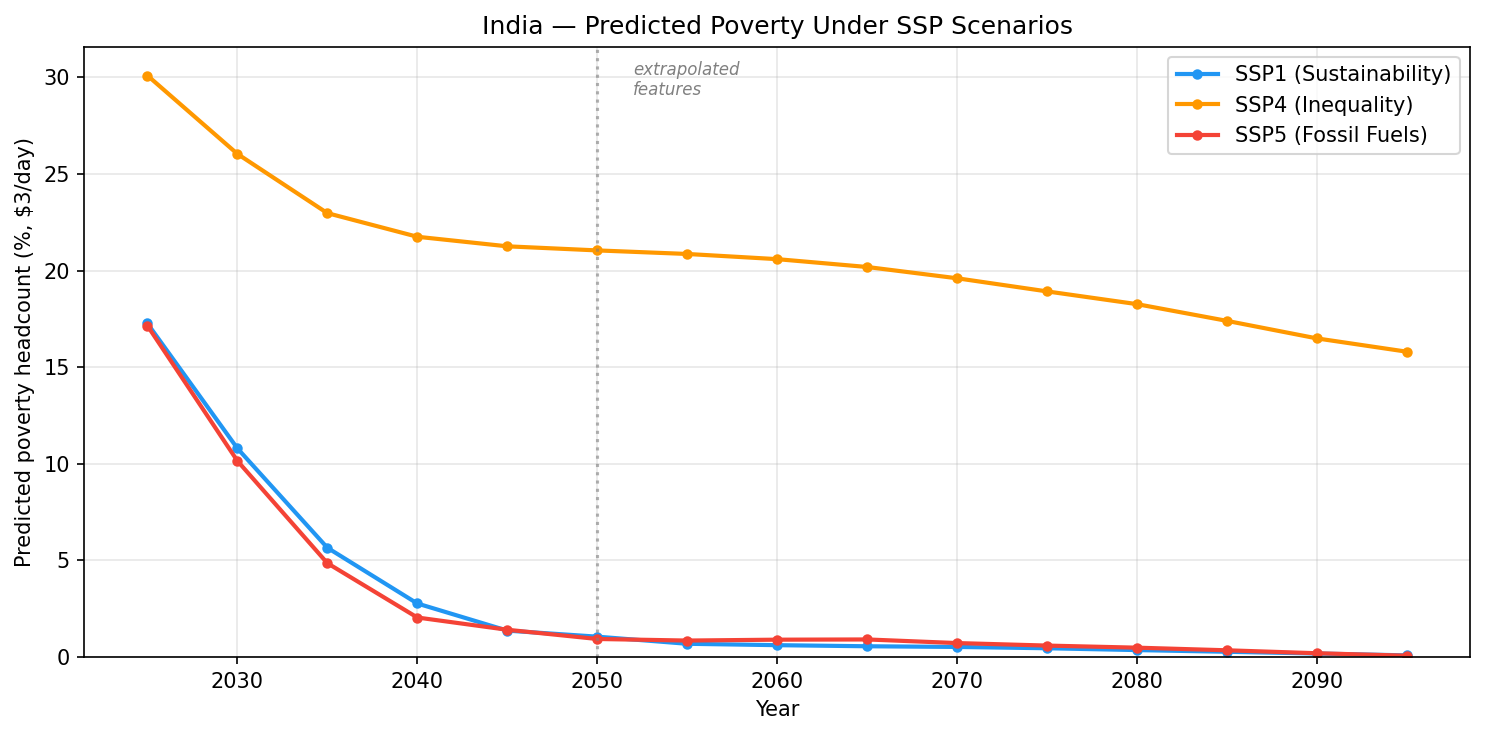

Saved: outputs/trajectory_plots/trajectory_India.png



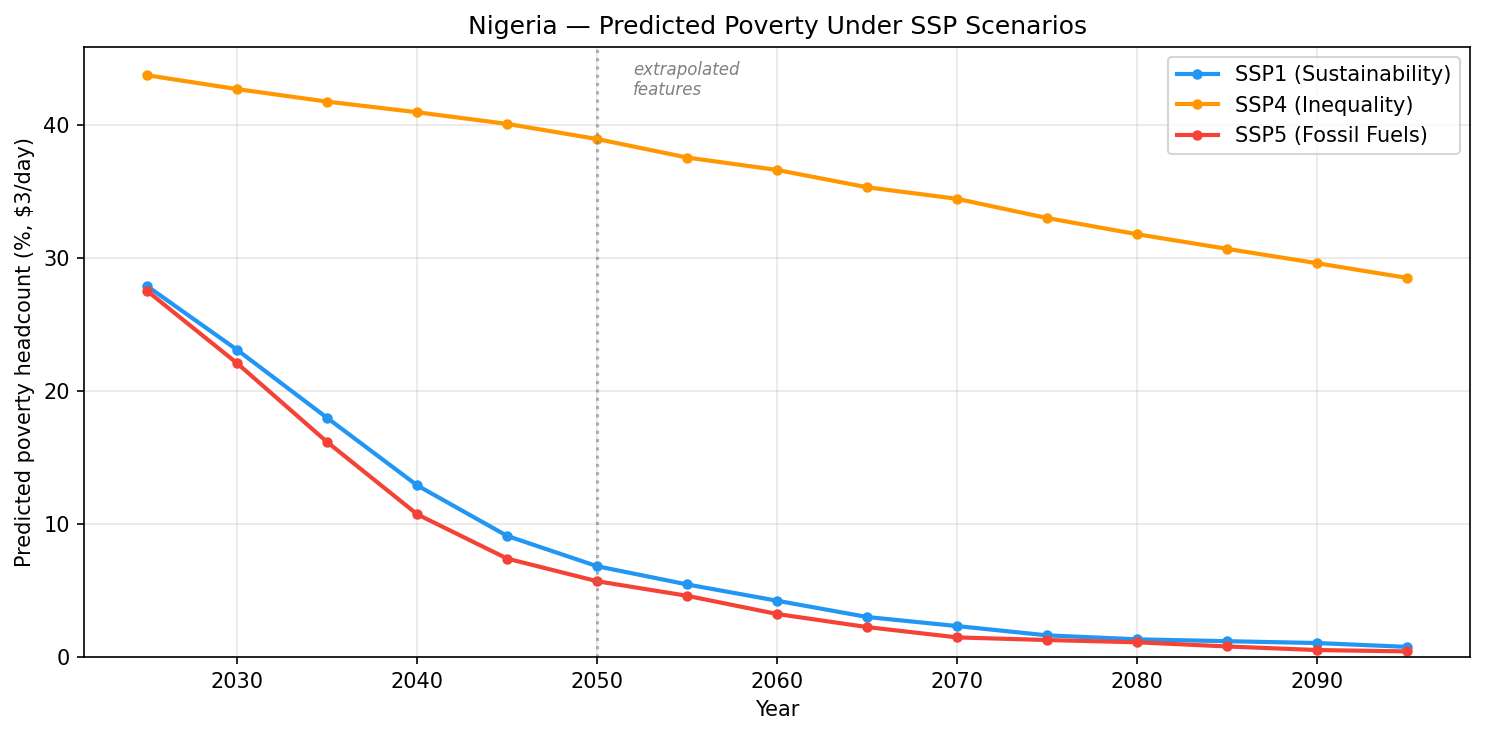

Saved: outputs/trajectory_plots/trajectory_Nigeria.png



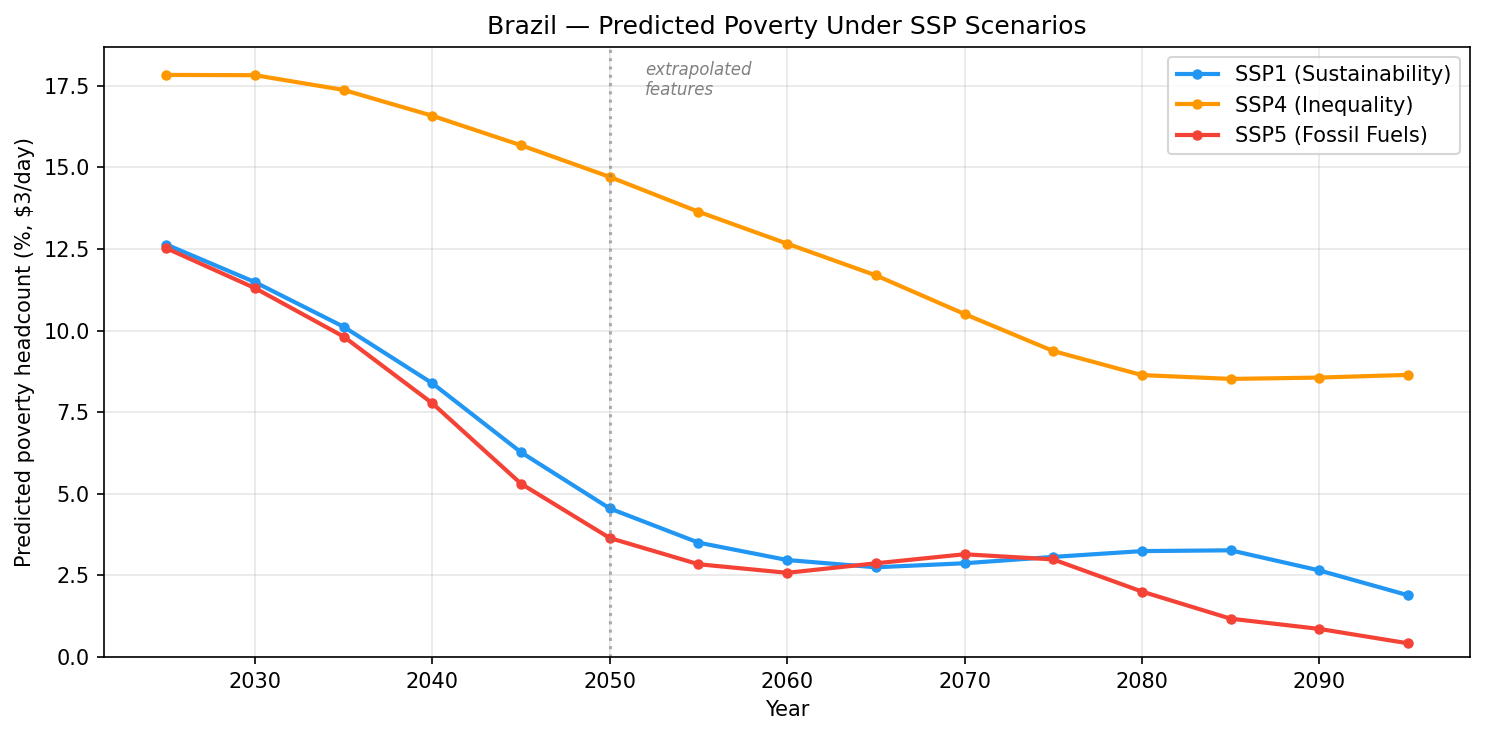

Saved: outputs/trajectory_plots/trajectory_Brazil.png



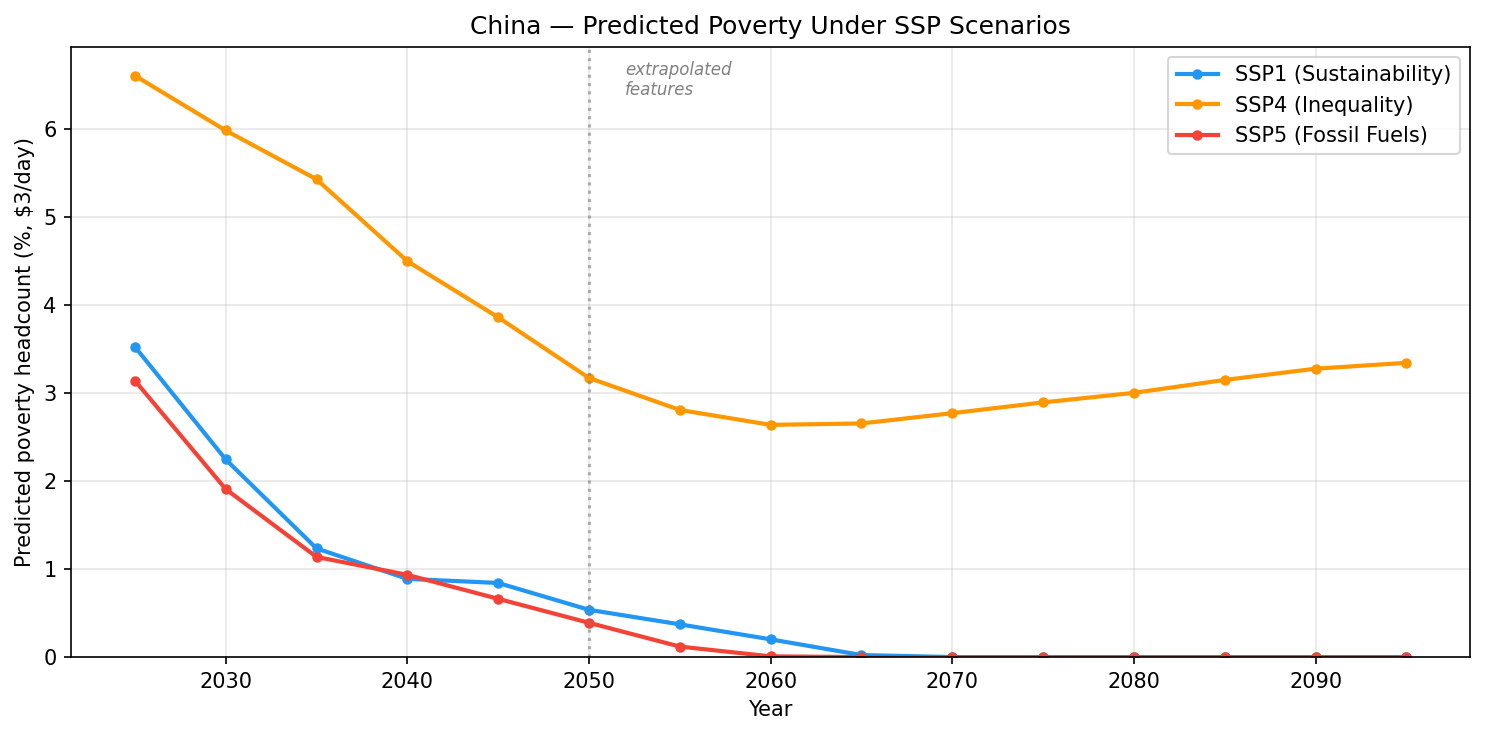

Saved: outputs/trajectory_plots/trajectory_China.png



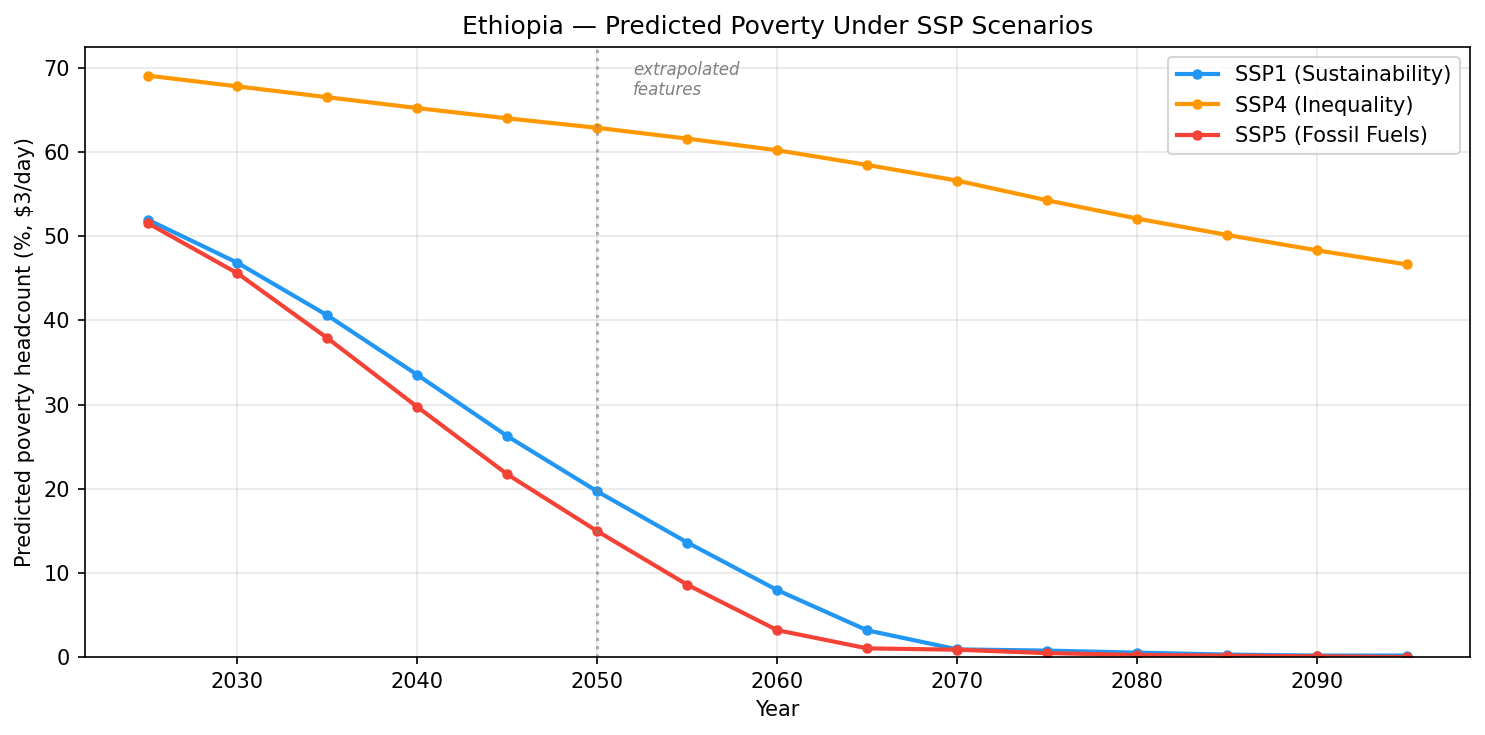

Saved: outputs/trajectory_plots/trajectory_Ethiopia.png



In [10]:
# Filter to Approach B, poverty_3
traj_data = predictions[
    (predictions["approach"] == "B") &
    (predictions["poverty_threshold"] == "poverty_3")
]

scenario_colors = {"SSP1": "#2196F3", "SSP4": "#FF9800", "SSP5": "#F44336"}
scenario_labels = {
    "SSP1": "SSP1 (Sustainability)",
    "SSP4": "SSP4 (Inequality)",
    "SSP5": "SSP5 (Fossil Fuels)"
}

for country in EXAMPLE_COUNTRIES:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    df_c = traj_data[traj_data["country_name"] == country]
    
    for ssp in ["SSP1", "SSP4", "SSP5"]:
        df_s = df_c[df_c["scenario"] == ssp].sort_values("year")
        ax.plot(
            df_s["year"], df_s["predicted_poverty"],
            "o-", color=scenario_colors[ssp], label=scenario_labels[ssp],
            markersize=4, linewidth=2
        )
    
    # Mark extrapolation zone
    ax.axvline(x=2050, color="gray", linestyle=":", alpha=0.6)
    ax.text(2052, ax.get_ylim()[1] * 0.92, "extrapolated\nfeatures",
            fontsize=8, color="gray", style="italic")
    
    ax.set_xlabel("Year")
    ax.set_ylabel("Predicted poverty headcount (%, $3/day)")
    ax.set_title(f"{country} — Predicted Poverty Under SSP Scenarios")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    safe_name = country.replace(" ", "_")
    plt.savefig(TRAJ_DIR / f"trajectory_{safe_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: outputs/trajectory_plots/trajectory_{safe_name}.png")
    print()

## Summary statistics

In [11]:
# Global average predicted poverty by scenario and year (poverty_3, Approach A)
summary = (
    predictions[
        (predictions["approach"] == "A") &
        (predictions["poverty_threshold"] == "poverty_3")
    ]
    .groupby(["scenario", "year"])["predicted_poverty"]
    .mean()
    .unstack("scenario")
)

print("Global average predicted poverty (% at $3/day) — Approach A:")
print(summary.round(2))

Global average predicted poverty (% at $3/day) — Approach A:
scenario   SSP1   SSP4   SSP5
year                         
2025      16.00  23.07  15.80
2030      13.65  22.22  13.18
2035      11.38  21.50  10.62
2040       9.35  20.86   8.37
2045       7.51  20.29   6.41
2050       5.96  19.72   4.94


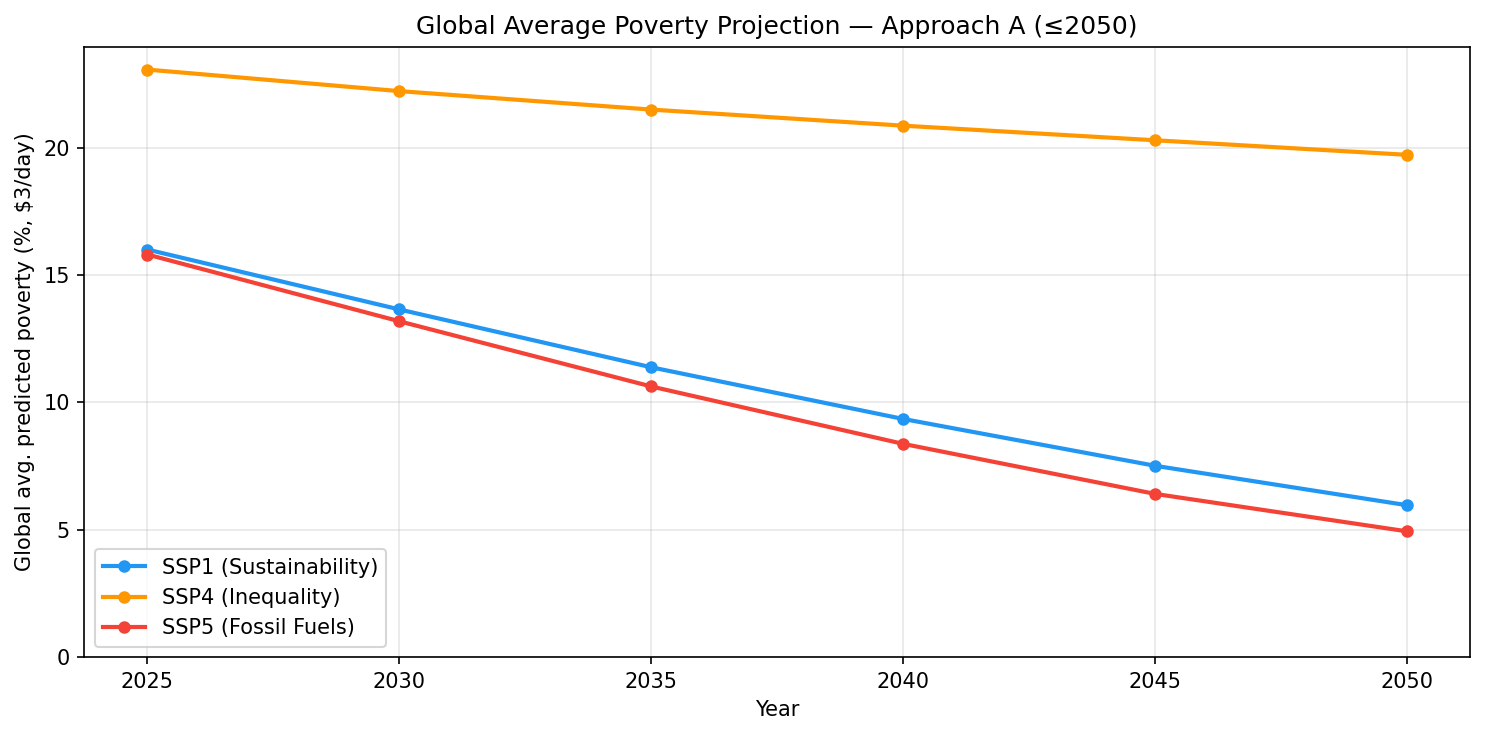

Saved: outputs/global_avg_poverty_projection.png


In [12]:
# Quick plot of global averages
fig, ax = plt.subplots(figsize=(10, 5))

for ssp in ["SSP1", "SSP4", "SSP5"]:
    ax.plot(summary.index, summary[ssp], "o-", color=scenario_colors[ssp],
            label=scenario_labels[ssp], markersize=5, linewidth=2)

ax.set_xlabel("Year")
ax.set_ylabel("Global avg. predicted poverty (%, $3/day)")
ax.set_title("Global Average Poverty Projection — Approach A (≤2050)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "global_avg_poverty_projection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/global_avg_poverty_projection.png")

---
**Outputs produced:**
- `data/processed/predictions_ssp.csv` — full prediction file for the dashboard team
- `outputs/top10_highest_poverty.csv` — top 10 highest-poverty countries per scenario at 2050
- `outputs/trajectory_plots/trajectory_{country}.png` × 5 — per-country trajectory plots
- `outputs/global_avg_poverty_projection.png` — global average trend

The `predictions_ssp.csv` file has columns:  
`country_name, country_code, scenario, year, poverty_threshold, predicted_poverty, approach`  
Approach A covers years ≤ 2050, Approach B covers all years up to 2100.